# Lab 8: Putting it all together!

**How you will be graded**

This activity is out of 10 points. You will be graded on three things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing.
* *Correctness (2pts)*: Does your code run and produce the correct output?


# Playground!

In this section you will be given a set of tasks to complete on your own, and you will have to figure out how to do them using the resources provided (videos, documentation, etc). This way you can learn at your own pace and also get used to looking up documentation and learning how to use new tools on your own.

The very first task is to import the required packages, this lab we will use all the concepts from previous labs to analyze a real biological network, everything here has been done in previous labs, so the amount of help in the notebook will be minimal (but you can still call me over if you get stuck!).

Try importing the required libraries below (dont forget you can use the `as` keyword to give them a shorter alias):

In [1]:
import networkx as nx 
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import polars as pl

# 1. Loading data

The very first step for any analyses is to load the data and create a network out of it. Our network of choice is the gap junction network for ***C. elegans***, below is the description from its website:

"Networks among neurons of both the adult male and adult hermaphrodite worms ***C. elegans***, constructed from electron microscopy series, to include directed edges (chemical) and undirected (gap junction), and spanning including nodes for muscle and non-muscle end organs.

The 'connectivity' edge property corresponds to the total number of EM serial sections of connectivity, taking into account both the number of synapses and the sizes of synapses.

To provide complete coverage of the entire nervous system, the data are assembled from multiple animals and include connections added by extrapolation in gaps where no data were available."

Your goal is to act like data scientists and perform some rudimentary analyses on this network, the analyses should be enough that you can inform a layman about the structure of this network.

Load the data using polars and create a graph out of it (draw the graph as well).


In [2]:
## filepath 

filepath  = "edges_gj.csv"

# read csv w polars
df = pl.read_csv(filepath, has_header=True)
df.head() 


source,target,connectivity
i64,i64,i64
2,0,2
3,1,1
4,1,1
5,2,1
8,3,1


# 2. Exploring the network

When we load a new network, the very first thing we should do is explore the very basic structure of our network. This means figuring out:

- How large is this network (number of nodes and edges)?
- Is the network fully connected, or are there multiple components?
- What does the degree distribution look like at first glance?

Some of these questions can be answered just by looking at the drawn network, but thats not enough, we still should quantify all these things.

Find out and print the following statistics for your network (Dont forget to store them in seperate variables, you might need these values later):
- Number of nodes
- Number of edges
- Average degree
- Network density
- Number and size of connected components

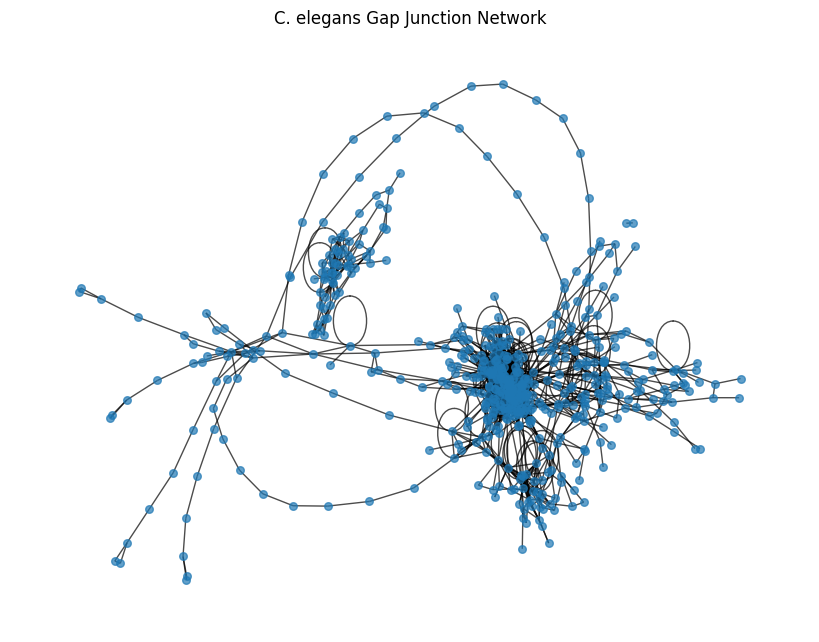

In [3]:
# convert df to pandas for networkx
# 
df_pd = df.to_pandas()

# create graph 
G = nx.from_pandas_edgelist(df_pd, source = "source", target = "target")


# Draw the network 
plt.figure(figsize=(8, 6))
nx.draw(G, node_size=30, alpha=0.7, with_labels=False)
plt.title("C. elegans Gap Junction Network")
plt.show()




In [4]:
# Number of nodes and edges
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Average degree = 2E/N (each edge adds 2 degrees)
avg_degree = 2 * num_edges / num_nodes

# Network density (how many edges exist vs possible)
density = nx.density(G)

# Connected components — how many separate subnetworks exist?
components = list(nx.connected_components(G))
num_components = len(components)
largest_component_size = len(max(components, key=len))

# --- Print results ---
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Average degree: {avg_degree:.2f}")
print(f"Network density: {density:.5f}")
print(f"Number of connected components: {num_components}")
print(f"Largest component size: {largest_component_size}")


Number of nodes: 543
Number of edges: 1758
Average degree: 6.48
Network density: 0.01195
Number of connected components: 3
Largest component size: 484


What do these number tell you? Write a line for each stat.

**Student answer here**

543 nodes indicates we have 543 different neurons in the worms. There are a total of 1758 connections between these 543 neurons. SO, each worm is connected to 6.48 other neurons on average. 

The network density of 0.01195 indicates the graph is not too dense. There are 3 different, isolated subgraphs. However, this is hard to see in our visualization of the graph becuase of the large number of nodes and connections. The largest of these components is 484 nodes, which is nearly 90% of our data. 

# 3. Degree distribution - What type of network is this?

Now we know some basic stuff about our network, but we still dont know what kind of structure it has (except the fact that its not connected). We know from theory that biological networks tend to be scale free, i.e. their degree distribution follows a power law.

Lets check if its true for this network as well.

For this task plot the degree distribution for this network in both the linear and log scale, also plot the fit line for both graphs. 

(**Extra credits (0.5)** if you plot them side by side using `plt.subplots`)

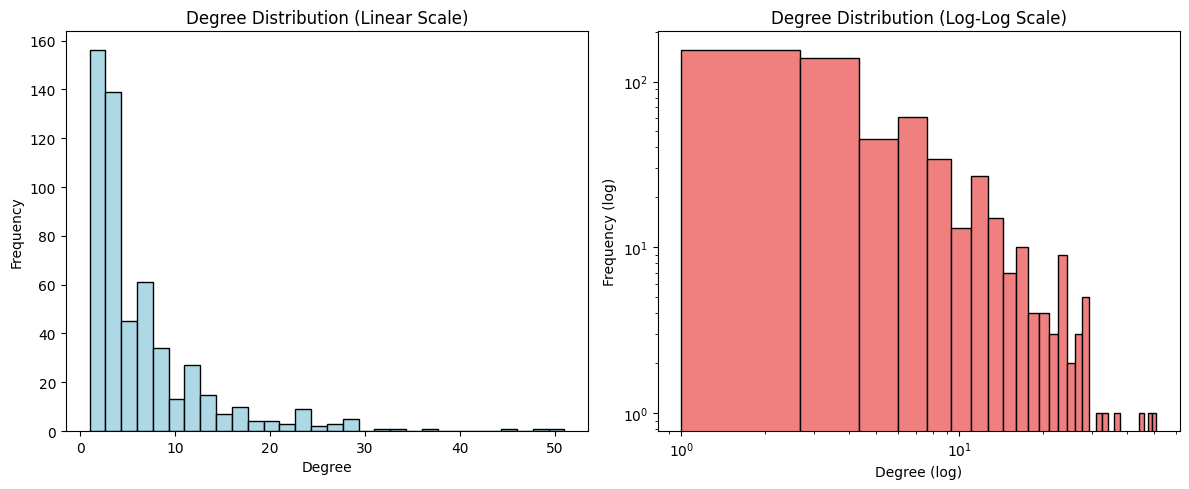

In [ ]:
#Compute degrees of all nodes 
degrees = [deg for _, deg in G.degree()]

# Plot degree distribution (linear scale) 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(degrees, bins=30, color='lightblue', edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution (Linear Scale)")

# Plot on log-log scale (scale free))
plt.subplot(1, 2, 2)
plt.hist(degrees, bins=30, color='lightcoral', edgecolor='black')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Frequency (log)")
plt.title("Degree Distribution (Log-Log Scale)")

plt.tight_layout()
plt.show()


- Does the degree distribution resemble that of a scale-free network?  
- Are there a few high-degree nodes? What might that imply biologically?

**Student answer here**

The linear graph shows us that a few number of nodes have many connections. Most nodes have very few connections. When we apply a log-log scale, we see a roughly straight, decreasing line. However, this line isn't perfrect and there are spikes in between. 

Yes, this degree distribution resembles a scale free network. The few-high degree nodes could indicate a few neurons that interact with many neurons (maybe like a communication hub). It also indicates vulnerability points, showing where networks could fall apart if the few central, high degree neuron fall apart. 

# 4. Centrality measures - Which nodes are more important?

Now that we know what type of structure we are dealing with, lets start zooming into the important components of this network. We know that a good way of figuring out which nodes are more valuable is by finding out their centrality measures, till now we have learnt about a few different types of centralities. Different centrality measures capture different ways of being “important” in a network:

In the code cell below print out the top 5 nodes for each of the following centrality measures,
- Eigenvector Centrality
- Betweenness Centrality
- Closeness Centrality

(**Hint**: Use the inbuilt networkx functions for this, its quick and practical. Look up these in the networkx documentation. For printing the top 5 nodes you can use the following code: `sorted(dict, key=dict.get, reverse=True)[:5]` where dict is your dictionary name. The output is a list of 5 nodes with the max values.)

In [6]:
# --- Eigenvector Centrality ---
eigen_centrality = nx.eigenvector_centrality(G, max_iter=1000)
top_eigen = sorted(eigen_centrality, key=eigen_centrality.get, reverse=True)[:5]
print("Top 5 Eigenvector Centrality nodes:", top_eigen)

# --- Betweenness Centrality ---
betweenness = nx.betweenness_centrality(G)
top_betweenness = sorted(betweenness, key=betweenness.get, reverse=True)[:5]
print("Top 5 Betweenness Centrality nodes:", top_betweenness)

# --- Closeness Centrality ---
closeness = nx.closeness_centrality(G)
top_closeness = sorted(closeness, key=closeness.get, reverse=True)[:5]
print("Top 5 Closeness Centrality nodes:", top_closeness)



Top 5 Eigenvector Centrality nodes: [439, 215, 216, 177, 504]
Top 5 Betweenness Centrality nodes: [215, 317, 294, 287, 216]
Top 5 Closeness Centrality nodes: [215, 504, 439, 177, 216]


- Do the same nodes appear important across multiple metrics?  
- What might these results mean for robustness of the connectome?
- What does each of these measures tell you about the nodes?

**Student answer here**

1 appearance: 317, 294, 287, 504

2 appearences: 439, 177, 504

3 appearences: 215, 216

Nodes with appearances in all 3 lists are highly-influential nodes in the worm neuron network. Nodes with 2 appearances are lightly less influential, but still significant. The nodes in betweenness (317, 294, 287) but not in the other lists are likely connection two subnetworks; this would make them critical to the structure, but not necessarily the most connected. 

# 5. Assortativity - Do similar nodes connect?

In networks, **assortativity** measures the tendency of nodes to connect to others that are similar in some property — like degree. It ranges from `-1` to `1`.

- A **positive assortativity** means high-degree nodes tend to connect with other high-degree nodes.  
- A **negative assortativity** means high-degree nodes connect more often with low-degree ones.
- A **zero assortativity** means there is no preference.  

This property could tell us something about how the network might respond to failures or disruptions.

Your task is to use networkx's inbuilt function to find and print the assortaticity for our network.

In [8]:
## assorativity 
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Assortativity coefficient: {assortativity:.4f}")

Assortativity coefficient: 0.2322


- Is it assortative or disassortative?  
- How might this pattern influence the network’s robustness to node loss (random or targeted)? What about networks with high positive or negative assortativity?
- Why might such a structure be biologically beneficial (or not) for a system?

**Student answer here**

our network is assorative becauase our value is positive. however, it isn't strongly associated because our coefficient is only 0.2. The more-connected nodes are relatively connected to other high-degree nodes. this would imply the network is more susceptible to attacks by taking out the higher-degree nodes that hold a majority of the network together.  



# 6. Putting it all together

- Reflect on your analyses and why you did it (apart from the fact that we asked you to)?
- What would you do differently if you were in a professional capacity and asked to analyse a unknown network?
- Is there a metric that was more insightful than others, and why?

**Student answer here**

This analysis helped me undersatnd how to begin exploring and charectarizing a real biological network. It showed how to identify community structure and identify functional modules within a larger network. 

It was also intersting to see applciations for the metrics we learn in class. We covered associativity earlier, and seeing it used to help understand this network makes the concept make more sense. THe same can be said for the centrality measures. I personally found the largest connected subnetwork to be the most insightful becaues it showed me nearly 90% of the data fell within one connected subnetwork. More importantly, it highlighted that there rae sets of neurons that form their own separate networks, which makes me wonder what role they play in the worm. 

If I were to analyse this network professionally, I think I would try including more visualzations with random seeds for consistency. This would help demonsrate my findings to those I am working with beyond statistics that some others may not understand. 

# Extra Credit (2 pts)

Some networks could have communities within them, we can use the function `nx.community.greedy_modularity_communities` to assign nodes to communities using the modularity maximization process.

For this extra credit I want you to list the number of communities in the network and the number of nodes in each community. 

Why do we see communities in a connectome network? What use might they be?

In [9]:
# --- Detect communities using greedy modularity maximization ---
from networkx.algorithms import community

communities = list(community.greedy_modularity_communities(G))

# Number of communities
num_communities = len(communities)

# Print basic info
print(f"Number of communities: {num_communities}")
print("Sizes of each community:")
for i, comm in enumerate(communities):
    print(f"Community {i+1}: {len(comm)} nodes")



Number of communities: 10
Sizes of each community:
Community 1: 119 nodes
Community 2: 113 nodes
Community 3: 86 nodes
Community 4: 62 nodes
Community 5: 57 nodes
Community 6: 52 nodes
Community 7: 46 nodes
Community 8: 4 nodes
Community 9: 2 nodes
Community 10: 2 nodes


this network can naturally be divided into 10 functional communities, indicating a modular substructure where some neurons are more tightly inter-connected than the rest of the network.These smaller, functional communities could represent different types of neurons, perhaps by their responsibility within the worm brain. 